# Image Segmentation

Image segmentation is a key technique in **computer vision** that breaks an image into meaningful parts, making it easier to analyze and process.  

### **Why is Image Segmentation Important?**
- **Divides an image into regions** based on pixel characteristics (color, intensity, texture).  
- **Simplifies image representation** by focusing only on important areas.  
- **Identifies objects and boundaries**, helping in tasks like object detection and recognition.  

### **Types of Segmentation**
- **Foreground vs. Background Separation** – Identifies the main object in an image.  
- **Region-based Segmentation** – Groups similar pixels together based on color, shape, or intensity.  

### **Where is it Used?**
- **Medical Imaging** – Identifying tumors in MRI or CT scans.  
- **Autonomous Vehicles** – Detecting lanes, pedestrians, and obstacles.  
- **Filmmaking & AR** – Background removal, video effects, and augmented reality.  

By segmenting an image into different parts, we can **focus only on the relevant regions** instead of processing the entire image.

<center><img src = "https://www.mathworks.com/discovery/image-segmentation/_jcr_content/mainParsys/band/mainParsys/lockedsubnav/mainParsys/columns_copy_974518203/1a6dd24b-5fad-4cb4-bf87-3fee7b1ee3e1/image.adapt.full.medium.jpg/1737349980485.jpg"> </img> </center>

## UNET

### **UNet: A Powerful Model for Image Segmentation**

UNet is a **Convolutional Neural Network (CNN)** specifically designed for **semantic image segmentation**. It was introduced by **Olaf Ronneberger, Philipp Fischer, and Thomas Brox in 2015** and has been widely used in **medical imaging** and other applications.

### **Why UNet?**
- **Pixel-wise Classification** – Unlike traditional CNNs used for classification, UNet labels **each pixel** in an image.
- **Encoder-Decoder Architecture** – Extracts features (encoder) and reconstructs them (decoder) to generate **detailed segmentations**.
- **Skip Connections** – Helps retain fine details by combining deep (abstract) and shallow (detailed) features.

### **Key Features of UNet**
- **Fully Convolutional Network (FCN)** – Can handle images of different sizes.
- **No Dense Layers** – Reduces computational cost and preserves spatial information.
- **Works Well with Limited Data** – Ideal for medical applications where labeled data is scarce.

### **Where is UNet Used?**
- **Medical Imaging** – Tumor detection, organ segmentation.
- **Satellite Image Analysis** – Land cover classification.
- **Autonomous Driving** – Lane and object detection.

UNet’s ability to perform **high-precision segmentation** makes it one of the most widely used architectures in computer vision!


## **UNET Architecture**

#### **Double Convolution in UNet**

In the UNet architecture, every stage consists of **two consecutive convolutional layers**. This pattern is followed consistently in both the **contracting (encoder) and expanding (decoder) paths**.

### **How it Works:**
- After the **input image tile**, we apply **two 3×3 convolutional layers** followed by **ReLU activation**.
- After each **Max Pooling layer (downward red arrow)** in the encoder, we again apply **two convolutional layers (blue arrows)**.
- In the **decoder (expanding path)**, after each **up-convolution (green arrow)**, we again use **two convolutional layers**.

### **Why Use a Function?**
- Since this **double convolution** is repeated multiple times, defining it as a **function** avoids redundancy.
- This makes the model **cleaner, modular, and reusable**.

By wrapping the **double convolution operation** into a function, we simplify the model-building process while maintaining consistency in the architecture.


<center><img src = "https://media.geeksforgeeks.org/wp-content/uploads/20220614121231/Group14.jpg"></img></center>

In [ ]:
import torch
import torch.nn as nn

def double_convolution(in_channels, out_channels):
    """
    This function creates a block of two consecutive convolutional layers,
    each followed by a ReLU activation function.

    Key Details:
    - Uses a kernel size of 3x3 to capture local patterns in the image.
    - Adds padding (padding=1) to maintain the same spatial dimensions
      (height & width) after convolution.
    - Uses ReLU activation (`inplace=True` improves memory efficiency).
    - This block is used repeatedly in both the encoder (contracting path)
      and decoder (expanding path) of the UNet model.

    Why Use This?
    - Avoids redundant code since UNet applies this structure multiple times.
    - Ensures consistency across the network.

    Expected Outcome:
    - Returns a **sequential layer** containing two convolutional operations
      with non-linearity applied, ready to be integrated into UNet.
    """
    conv_op = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),  # First 3x3 Conv
        nn.ReLU(inplace=True),  # Activation Function
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),  # Second 3x3 Conv
        nn.ReLU(inplace=True)  # Activation Function
    )
    return conv_op


We can see a Sequential block with two Conv2d layers followed by ReLU activation. We are using a padding of 1 for each of the convolutional layers. The padding ensures that the final segmentation map is the same size as the input image.

### **UNET Class**



*   In the `init` method, we begin by defining a MaxPool2d layer, which we'll apply after every downsampling module.

*   The contracting path, mirrors the architecture described in the paper. We use the double_convolution function with the appropriate number of in_channels and out_channels. This starts with 64 out_channels in the initial layer and gradually increases to 1024 out_channels just before transitioning to the expanding path.

*  We also specify the layer configurations for the expanding path, utilizing 2D Transposed Convolutional layers. The first layer in the expanding path reduces the output channels from 1024 to 512. Subsequently, we outline the remaining layer configurations for double_convolution and transposed convolution.

*  Each double_convolution definition in the expanding path doubles the number of in_channels compared to the out_channels of the preceding transposed convolution. Why? It relates to the implementation of skip connections. These connections between the contracting and expanding paths operate along the channel axis. Thus, prior to the double convolutions, the input channels are doubled to accommodate these connections effectively.

* The `forward` method orchestrates the sequential application of all layers in the correct sequence. For each transposed convolutional layer in the expanding path, a double convolution block is employed.

* Commencing with the contracting path, we observe alternating downsampling and max-pooling operations. Adhering to the original UNet design, there is no max-pooling applied after the last downsampling block. This is the point where the number of output channels reaches 1024.

* In the layers for the expanding path, the double convolutions follow the transposed convolution layers. Notably, the concatenation process operates in reverse order. In other words, the first transposed convolutional layer concatenates along the channel axis with the final downsampled block, and this pattern continues.

* The ultimate layer possesses an output channel count equivalent to the number of classes in the dataset. Additionally, since it's a segmentation architecture and we require the final feature map without spatial resolution reduction, the last layer almost always employs a kernel size of 1.



In [ ]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    """
    Implementation of a U-Net architecture for semantic segmentation.

    The U-Net consists of:
    - A **contracting path (encoder)** to capture image features.
    - An **expanding path (decoder)** to reconstruct the segmented image.
    - **Skip connections** to retain fine details from earlier layers.

    Args:
        num_classes (int): Number of classes for segmentation.

    Expected Output:
    - The model generates a segmentation mask with pixel-wise class predictions.
    - The final layer produces an output tensor with shape (batch_size, num_classes, height, width).
    """

    def __init__(self, num_classes):
        super(UNet, self).__init__()

        # Downsampling (Encoder) - Captures important image features
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)  # Reduces spatial size by half

        self.down_convolution_1 = double_convolution(3, 64)   # Initial layer (input: RGB image)
        self.down_convolution_2 = double_convolution(64, 128)
        self.down_convolution_3 = double_convolution(128, 256)
        self.down_convolution_4 = double_convolution(256, 512)
        self.down_convolution_5 = double_convolution(512, 1024)  # Deepest layer with highest feature extraction

        # Upsampling (Decoder) - Restores spatial resolution
        self.up_transpose_1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)  # Upsampling
        self.up_convolution_1 = double_convolution(1024, 512)  # Skip connection from encoder

        self.up_transpose_2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_convolution_2 = double_convolution(512, 256)

        self.up_transpose_3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_convolution_3 = double_convolution(256, 128)

        self.up_transpose_4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_convolution_4 = double_convolution(128, 64)

        # Final output layer - Produces segmentation mask
        self.out = nn.Conv2d(64, num_classes, kernel_size=1)  # Output mask with num_classes channels

    def forward(self, x):
        """
        Forward pass of the U-Net model.

        Process:
        - Encoder: Extracts features using convolution and max pooling.
        - Decoder: Upsamples and concatenates features from the encoder.
        - Output: Returns a segmentation mask.

        Args:
            x (torch.Tensor): Input image tensor of shape (batch_size, 3, H, W).

        Returns:
            out (torch.Tensor): Segmented output tensor.
            layer_outputs (list): Intermediate layer sizes for analysis.
        """

        layer_outputs = []  # Stores intermediate outputs for debugging or visualization

        # Contracting Path (Encoder)
        down_1 = self.down_convolution_1(x)
        layer_outputs.append(down_1.size())

        down_2 = self.max_pool2d(down_1)
        down_3 = self.down_convolution_2(down_2)
        layer_outputs.append(down_3.size())

        down_4 = self.max_pool2d(down_3)
        down_5 = self.down_convolution_3(down_4)
        layer_outputs.append(down_5.size())

        down_6 = self.max_pool2d(down_5)
        down_7 = self.down_convolution_4(down_6)
        layer_outputs.append(down_7.size())

        down_8 = self.max_pool2d(down_7)
        down_9 = self.down_convolution_5(down_8)
        layer_outputs.append(down_9.size())

        # Expanding Path (Decoder) with Skip Connections
        up_1 = self.up_transpose_1(down_9)
        x = self.up_convolution_1(torch.cat([down_7, up_1], 1))  # Skip connection
        layer_outputs.append(x.size())

        up_2 = self.up_transpose_2(x)
        x = self.up_convolution_2(torch.cat([down_5, up_2], 1))
        layer_outputs.append(x.size())

        up_3 = self.up_transpose_3(x)
        x = self.up_convolution_3(torch.cat([down_3, up_3], 1))
        layer_outputs.append(x.size())

        up_4 = self.up_transpose_4(x)
        x = self.up_convolution_4(torch.cat([down_1, up_4], 1))
        layer_outputs.append(x.size())

        out = self.out(x)  # Final segmentation mask output
        layer_outputs.append(out.size())

        return out, layer_outputs  # Output and intermediate layer sizes


### **Running a Sample Input Through UNet**

This code initializes a **UNet model**, generates a **random input image**, and calculates the **total and trainable parameters** in the model. Finally, it performs a **forward pass** through the network.

- **Creating a Sample Input**
  - A **random 512×512 RGB image** is created for testing the model.
  - The batch size is `1`, meaning a single image is being processed.

- **Initializing the UNet Model**
  - `UNet(num_classes=10)` initializes the network with **10 segmentation classes**.

- **Counting Parameters**
  - **Total Parameters** → All parameters in the model (trainable + non-trainable).
  - **Trainable Parameters** → Only those parameters that get updated during training.

- **Forward Pass**
  - The input image is passed through the model to generate a **segmentation mask**.
  - `layer_sizes` stores intermediate feature map sizes for debugging and analysis.


In [ ]:
import torch

# Create a random input tensor representing an image with:
# - Batch size = 1
# - 3 color channels (RGB)
# - Image dimensions = 512 x 512
input_image = torch.rand((1, 3, 512, 512))

# Initialize the UNet model with 10 output classes (for segmentation)
model = UNet(num_classes=10)

# Compute the total number of parameters in the model
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")  # Display total parameters

# Compute the total number of trainable parameters (those with requires_grad=True)
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")  # Display trainable parameters

# Perform a forward pass: Pass the input image through the model
output, layer_sizes = model(input_image)


31,032,330 total parameters.
31,032,330 training parameters.


### **Layer Outputs in UNet**



This section helps us visualize how the input image **changes in size** as it moves through each layer of the UNet model. It is useful for understanding the transformations happening in both the **contracting (encoder) and expanding (decoder) paths**.


### **Expected Output**
- **First few layers (Encoder)** → The spatial dimensions **decrease** while feature channels **increase** (downsampling).
- **Middle layer (Bottleneck)** → The smallest spatial size with the highest feature representation.
- **Final layers (Decoder)** → The spatial size **restores** to its original dimensions (upsampling).
- **Final output size** → `(1, 10, 512, 512)`, meaning:
  - `1` → Batch size  
  - `10` → Number of segmentation classes  
  - `512 × 512` → Output resolution (same as input)  

This confirms that UNet correctly processes the image while maintaining spatial details using skip connections


In [ ]:
print(output.shape)
# Print dimensions after each layer
for i, size in enumerate(layer_sizes):
    print(f"Layer {i+1} output size: {size}")
print(f"Final output size: {output.size()}")

torch.Size([1, 10, 512, 512])
Layer 1 output size: torch.Size([1, 64, 512, 512])
Layer 2 output size: torch.Size([1, 64, 256, 256])
Layer 3 output size: torch.Size([1, 128, 256, 256])
Layer 4 output size: torch.Size([1, 128, 128, 128])
Layer 5 output size: torch.Size([1, 256, 128, 128])
Layer 6 output size: torch.Size([1, 256, 64, 64])
Layer 7 output size: torch.Size([1, 512, 64, 64])
Layer 8 output size: torch.Size([1, 512, 32, 32])
Layer 9 output size: torch.Size([1, 1024, 32, 32])
Layer 10 output size: torch.Size([1, 512, 64, 64])
Layer 11 output size: torch.Size([1, 256, 128, 128])
Layer 12 output size: torch.Size([1, 128, 256, 256])
Layer 13 output size: torch.Size([1, 64, 512, 512])
Layer 14 output size: torch.Size([1, 10, 512, 512])
Final output size: torch.Size([1, 10, 512, 512])


## **Image Segmentation**

**Binary Segmentation** is the process of classifying each pixel in an image into one of two categories:
- **Foreground** → Pixels belonging to the object of interest.
- **Background** → Pixels belonging to the surrounding area.

This technique is commonly used in applications like **medical imaging**, **autonomous vehicles**, and **object detection**.

We will use the **segmentation-models-pytorch** library, which provides ready-to-use deep learning models for segmentation tasks.

- segmentation-models-pytorch → A PyTorch-based library for various segmentation architectures (UNet, DeepLabV3, etc.).
- pytorch-lightning → Simplifies model training and scaling.

In [ ]:
!pip install segmentation-models-pytorch
!pip install pytorch-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.6 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16428 sha256=68a168155f1177203dd30ce0f44cebef3932b599192ff77e6845f915f03b577c
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=abead90698dcb3a0986d9d193c915e16bed45738a3adbad98be85134fc60a079
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 

### **Importing Required Libraries**


In [ ]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import segmentation_models_pytorch as smp

from pprint import pprint
from torch.utils.data import DataLoader

### **Dataset Loading: SimpleOxfordPetDataset**


We will use the **SimpleOxfordPetDataset**, a commonly used dataset for **image segmentation** tasks.

- **Derived from the Oxford-IIIT Pet Dataset** which contains images of **various cat and dog breeds**.
- Provides **pixel-level annotations**, making it useful for **segmentation tasks**.
- The **simplified version** focuses on **binary or multi-class segmentation**:
  - **Binary segmentation** → Identifying pets vs. background.
  - **Multi-class segmentation** → Differentiating between "cats" and "dogs" as separate classes.


<center><img src = "https://production-media.paperswithcode.com/datasets/Oxford-IIIT_Pets-0000000571-4547798f_WG4TMz3.jpg"></img></center>

Before training our segmentation model, we need to **download the dataset**.  
The **SimpleOxfordPetDataset** from `segmentation_models_pytorch.datasets` provides **pre-processed images and segmentation masks**, making it easy to use for training.

The dataset consists of:
- **Images** of various cat and dog breeds.
- **Segmentation masks** where each pixel represents a specific class (e.g., pet vs. background).

Below is the code to download the dataset.

In [ ]:
# Import the SimpleOxfordPetDataset class from segmentation_models_pytorch
from segmentation_models_pytorch.datasets import SimpleOxfordPetDataset

# Define the directory where the dataset will be downloaded
root = "."  # The current directory

# Download the dataset to the specified directory
SimpleOxfordPetDataset.download(root)

images.tar.gz: 100%|██████████| 755M/755M [00:37<00:00, 21.2MB/s]
annotations.tar.gz: 100%|██████████| 18.3M/18.3M [00:03<00:00, 4.91MB/s]


### **Loading the Dataset for Training, Validation, and Testing**

To train our segmentation model, we need to split the dataset into **training, validation, and test sets**.  
This ensures that:
- **Training data** is used to learn model parameters.
- **Validation data** is used to fine-tune hyperparameters.
- **Test data** evaluates final model performance.

In [ ]:
# Load the dataset into three sets: train, validation, and test
train_dataset = SimpleOxfordPetDataset(root, "train")
valid_dataset = SimpleOxfordPetDataset(root, "valid")
test_dataset = SimpleOxfordPetDataset(root, "test")

In [ ]:
print(f"Train size: {len(train_dataset)}")
print(f"Valid size: {len(valid_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 3312
Valid size: 368
Test size: 3669


In [ ]:
train_dataset[3311]

{'image': array([[[128, 129, 131, ...,   6,   6,   5],
         [135, 137, 138, ...,   6,   6,   5],
         [140, 142, 144, ...,   6,   6,   6],
         ...,
         [ 81,  84,  85, ...,  71,  75,  67],
         [ 88,  85,  81, ...,  75,  75,  74],
         [ 89,  86,  88, ...,  81,  76,  71]],
 
        [[118, 118, 116, ...,   6,   6,   5],
         [124, 123, 120, ...,   6,   6,   5],
         [130, 128, 126, ...,   6,   6,   6],
         ...,
         [ 42,  44,  45, ...,  35,  38,  31],
         [ 47,  48,  43, ...,  36,  35,  36],
         [ 48,  48,  48, ...,  41,  35,  33]],
 
        [[110, 108, 103, ...,   6,   6,   5],
         [115, 113, 107, ...,   6,   6,   5],
         [121, 119, 114, ...,   6,   6,   6],
         ...,
         [ 50,  51,  52, ...,  41,  44,  37],
         [ 55,  54,  50, ...,  42,  42,  43],
         [ 56,  56,  56, ...,  46,  41,  38]]], dtype=uint8),
 'mask': array([[[1., 1., 1., ..., 0., 0., 0.],
         [1., 0., 0., ..., 0., 0., 0.],
         [1

### **Using Dataloaders for Efficient Data Handling**


Dataloaders are essential in PyTorch for **efficiently loading and batching data**.  
They help:
- **Process large datasets in small batches** to optimize memory usage.
- **Shuffle data** to prevent learning biases.
- **Utilize multiple CPU cores** to load data faster.



In [ ]:
# Get the number of available CPU cores for parallel data loading
n_cpu = os.cpu_count()

# Create DataLoaders for training, validation, and test sets
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=n_cpu)
valid_dataloader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=n_cpu)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=n_cpu)

In [ ]:
train_dataloader

### **Plotting some images from the Datasets**

Before training our segmentation model, let's inspect the dataset structure.  
We will check how many segmentation masks are available for an image.

In [ ]:
# Check the number of segmentation masks for the first image in the training dataset
len(train_dataset[0]['mask'])

1

### **Visualizing Sample Images and Segmentation Masks**

To better understand our dataset, we will **visualize images and their corresponding segmentation masks**.  
Each sample consists of:
- **An image** (RGB).
- **A mask** where each pixel represents a labeled class (e.g., pet vs. background).


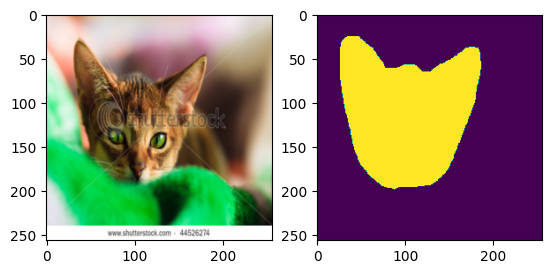

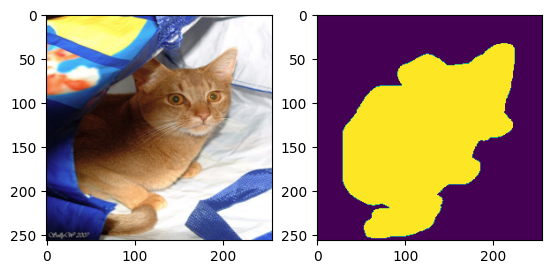

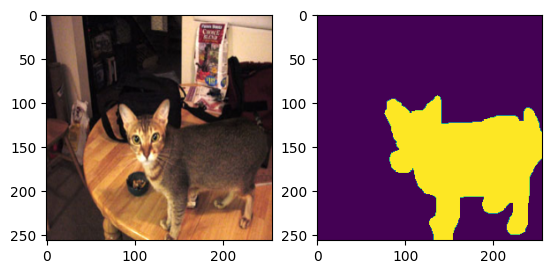

In [ ]:
# Visualize a sample from the training dataset
sample = train_dataset[0]
plt.subplot(1,2,1)
plt.imshow(sample["image"].transpose(1, 2, 0))  # Convert from CHW to HWC format for visualization
plt.subplot(1,2,2)
plt.imshow(sample["mask"].squeeze())  # Remove extra dimension from mask
plt.show()

# Visualize a sample from the validation dataset
sample = valid_dataset[0]
plt.subplot(1,2,1)
plt.imshow(sample["image"].transpose(1, 2, 0))
plt.subplot(1,2,2)
plt.imshow(sample["mask"].squeeze())
plt.show()

# Visualize a sample from the test dataset
sample = test_dataset[0]
plt.subplot(1,2,1)
plt.imshow(sample["image"].transpose(1, 2, 0))
plt.subplot(1,2,2)
plt.imshow(sample["mask"].squeeze())
plt.show()

### **Creating the Segmentation Model**



To perform image segmentation, we define a **custom PyTorch model** using `segmentation_models_pytorch (smp)`.  
This model:
- Loads a **pretrained segmentation architecture**.
- Applies **image preprocessing** (normalization).
- Uses **Dice Loss** for better segmentation performance.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Define the segmentation model
class PetModel(nn.Module):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()

        # Create a model using smp (segmentation_models_pytorch)
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs
        )

        # Preprocessing parameters for input normalization
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.std = torch.tensor(params["std"]).view(1,3,1,1).to(device)
        self.mean = torch.tensor(params["mean"]).view(1,3,1,1).to(device)

        # Define loss function - Dice Loss is ideal for segmentation
        self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

    def forward(self, image):
        # Normalize the image using mean and standard deviation
        image = (image - self.mean) / self.std

        # Forward pass through the segmentation model
        mask = self.model(image)
        return mask

### **Initializing the Pet Segmentation Model**


We are now **creating an instance of the `PetModel` class**, which is specifically designed for **semantic segmentation of pet images**.  
This model is built using **UNet** with a **ResNet-34 encoder**, a popular architecture for segmentation tasks.

An instance of the PetModel class is being created below. This class is designed for semantic segmentation tasks in the context of pet image analysis. The segmentation model architecture being used is specified as "FPN," and the encoder architecture is set to "resnet34."

Arguments:

* "Unet": This is the architecture identifier for Unet.
* "resnet34": This indicates the choice of the ResNet-34 architecture as the encoder. ResNet (Residual Network) is a popular deep neural network architecture known for its effectiveness in image-related tasks.
* in_channels=3: This specifies that the input images have three channels, typically representing RGB color channels.
* out_classes=1: This parameter sets the number of output classes for the segmentation task, which is 1 in this case, implying binary segmentation where the goal is to distinguish between one class (e.g., "object" vs. "background").

The resulting model object can be used for training, validation, and testing of the segmentation model on pet images, with the specified architecture and encoder settings.

In [ ]:
# Create the segmentation model with specified architecture and encoder
model = PetModel("Unet", "resnet34", in_channels=3, out_classes=1)

In [ ]:
model = model.to(device)

### **Loss Function in Image Segmentation**


Loss functions measure the **difference between the predicted output and the actual target values**.  
For segmentation tasks, choosing the right loss function is crucial to **accurately classify each pixel**.

- **Common loss functions include**:
  - **Cross-Entropy Loss** → Used for classification tasks.
  - **Mean Squared Error (MSE)** → Used in regression models.
  - **Dice Loss** → Specifically designed for **segmentation tasks**.

Since segmentation requires **pixel-wise classification**, **Dice Loss** is often the best choice as it helps the model focus on the shape and boundaries of the segmented object.

In [ ]:
# Define the loss function for segmentation
loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

### **Learning Rate in Model Training**

The **learning rate (lr)** is a key **hyperparameter** that controls:
- **How much the model updates its weights** during training.
- **The speed of convergence** to an optimal solution.

Choosing the right learning rate is important:
- **Too high** → The model may not converge and oscillate.
- **Too low** → The model may take too long to train.

For segmentation tasks, a small learning rate **ensures stable training and better accuracy**.


In [ ]:
# Define the learning rate
lr = 0.0001

### **Optimizer and Metrics Calculation in Model Training**

Optimizers are responsible for updating the model’s parameters **based on the gradients** computed during backpropagation.  
Different optimizers affect how quickly and effectively the model learns.

### **Why Adam Optimizer?**
- **Adaptive Learning Rate** → Adjusts step size for each parameter.
- **Works well with segmentation models** and deep learning architectures.
- **Less sensitive to hyperparameter tuning** compared to SGD.

### **Explanation of the Code**
- **`torch.optim.Adam()`** → Implements the Adam optimization algorithm.
- **`model.parameters()`** → Passes all model parameters to be optimized.
- **`lr=lr`** → Uses the learning rate (`0.0001`) defined earlier.

### **Expected Outcome**
- The model's weights will be updated efficiently during training.  
- Helps in achieving faster convergence and **better segmentation accuracy**.


In [ ]:
# Define the optimizer (Adam Optimizer)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

### **Computing Segmentation Metrics (IoU)**

### **Why Use IoU for Segmentation?**
- **Intersection over Union (IoU)** measures how well the predicted segmentation mask aligns with the ground truth.
- IoU is a **crucial metric** for evaluating segmentation models.

In [ ]:
def calculate_metrics(metrics, stage="train"):
    # Aggregate metrics across batches
    tp = torch.cat([x["tp"] for x in metrics])  # True Positives
    fp = torch.cat([x["fp"] for x in metrics])  # False Positives
    fn = torch.cat([x["fn"] for x in metrics])  # False Negatives
    tn = torch.cat([x["tn"] for x in metrics])  # True Negatives

    # Compute IoU per image and across the dataset
    per_image_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro-imagewise")
    dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

    # Store and return computed metrics
    metrics = {
        f"{stage}_per_image_iou": per_image_iou.cpu().item(),
        f"{stage}_dataset_iou": dataset_iou.cpu().item()
    }
    return metrics


### **Training a Single Batch (Train Step)**


The following function defines **one training step per epoch**, where the model:
1. **Processes a batch of images**.
2. **Computes the segmentation loss**.
3. **Updates model weights using backpropagation**.
4. **Logs training loss and evaluation metrics**.

In [ ]:
def train_batch(epoch, model, optimizer, loss_history, metric_history):
    print("epoch ", epoch)
    model.train()
    train_loss = 0
    step_metrics = []

    for batch_idx, batch in enumerate(train_dataloader):
        image = batch["image"]
        # shape of the image should be (batch_size, num_channels, height, width)
        h, w = image.shape[2:]
        mask = batch["mask"]

        # Move data to GPU if available
        image = image.to(device)
        mask = mask.to(device)

        # Forward pass: Get model predictions (logits)
        logits_mask = model(image)

        # Compute Dice Loss (compares predicted vs. ground truth mask)
        loss = loss_fn(logits_mask, mask)

        # Convert logits to probabilities and apply a threshold (0.5)
        prob_mask = logits_mask.sigmoid()
        pred_mask = (prob_mask > 0.5).float()

        # Backpropagation: Zero gradients, compute gradients, update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track total loss for the epoch
        train_loss += loss.item()

        # Compute segmentation metrics (True Positives, False Positives, etc.)
        tp, fp, fn, tn = smp.metrics.get_stats(pred_mask.long(), mask.long(), mode='binary')
        metrics = {
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn
        }

        # Store batch metrics
        step_metrics.append(metrics)

    # Calculate overall epoch metrics
    metrics = calculate_metrics(step_metrics)
    metric_history.append(metrics)
    loss_history.append(train_loss)

    # Print epoch loss and metrics
    print('Train Loss: %.3f' % (train_loss / (batch_idx + 1)))
    print("Train Metrics: ", metrics)


### **Validation Step: Evaluating Model Performance on Validation Data**

In [ ]:
def validate_batch(epoch, model, loss_history, metric_history):
    global best_acc
    model.eval()  # Set model to evaluation mode
    val_loss = 0
    step_metrics = []

    # Disable gradient calculation to save memory and speed up validation
    with torch.no_grad():
        for batch_idx, batch in enumerate(valid_dataloader):
            image = batch["image"]
            # shape of the image should be (batch_size, num_channels, height, width)
            h, w = image.shape[2:]
            mask = batch["mask"]

            # Move images and masks to GPU/CPU
            image = image.to(device)
            mask = mask.to(device)

            # Forward pass: Get model predictions
            logits_mask = model(image)

            # Compute loss (Dice Loss)
            loss = loss_fn(logits_mask, mask)

            # Convert logits to probabilities and apply a threshold (0.5)
            prob_mask = logits_mask.sigmoid()
            pred_mask = (prob_mask > 0.5).float()

            # Accumulate total validation loss
            val_loss += loss.item()

            # Compute segmentation metrics (True Positives, False Positives, etc.)
            tp, fp, fn, tn = smp.metrics.get_stats(pred_mask.long(), mask.long(), mode='binary')
            metrics = {
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn
            }

            # Store batch metrics
            step_metrics.append(metrics)

    # Calculate overall validation metrics
    metrics = calculate_metrics(step_metrics, "val")
    metric_history.append(metrics)
    loss_history.append(val_loss)

    # Print validation loss and metrics
    print('Val Loss: %.3f' % (val_loss / (batch_idx + 1)))
    print("Val Metrics: ", metrics)


### **Training Loop for Model**

- This code runs a training loop for 15 epochs.
- It starts from `start_epoch` (set to 0) and iterates for 15 epochs.
- The training loss, validation loss, and performance metrics are recorded.
- `train_batch()` is used to train the model on batches of data.
- `validate_batch()` is called to check the model’s performance after each epoch.

In [ ]:
# Initializing variables for training
start_epoch = 0  # Starting epoch
train_loss_history = []  # List to store training loss after each epoch
val_loss_history = []  # List to store validation loss after each epoch
train_metric_history = []  # List to store training metric (e.g., accuracy) after each epoch
val_metric_history = []  # List to store validation metric after each epoch

# Training loop - runs for 15 epochs
for epoch in range(start_epoch, start_epoch + 15):
    # Train the model for one epoch and update training loss & metrics
    train_batch(epoch, model, optimizer, train_loss_history, train_metric_history)

    # Validate the model on validation data and store validation loss & metrics
    validate_batch(epoch, model, val_loss_history, val_metric_history)

epoch  0
Train Loss: 0.206
Train Metrics:  {'train_per_image_iou': 0.8170149922370911, 'train_dataset_iou': 0.8246486186981201}
Val Loss: 0.118
Val Metrics:  {'val_per_image_iou': 0.8858691453933716, 'val_dataset_iou': 0.8943339586257935}
epoch  1
Train Loss: 0.090
Train Metrics:  {'train_per_image_iou': 0.8949059844017029, 'train_dataset_iou': 0.9031150341033936}
Val Loss: 0.082
Val Metrics:  {'val_per_image_iou': 0.8907820582389832, 'val_dataset_iou': 0.8985745906829834}
epoch  2
Train Loss: 0.064
Train Metrics:  {'train_per_image_iou': 0.9077069163322449, 'train_dataset_iou': 0.9159877896308899}
Val Loss: 0.065
Val Metrics:  {'val_per_image_iou': 0.8972076773643494, 'val_dataset_iou': 0.9050334692001343}
epoch  3
Train Loss: 0.052
Train Metrics:  {'train_per_image_iou': 0.9151848554611206, 'train_dataset_iou': 0.9239588379859924}
Val Loss: 0.064
Val Metrics:  {'val_per_image_iou': 0.8858593106269836, 'val_dataset_iou': 0.8961020708084106}
epoch  4
Train Loss: 0.047
Train Metrics:  {

### **Loss Visualization Using Matplotlib**

- This code plots the training and validation loss over epochs using Matplotlib.
- It helps visualize how well the model is learning and whether it's overfitting or underfitting.
- `train_loss_history` and `val_loss_history` contain the recorded loss values after each epoch.
- The x-axis represents the number of epochs, while the y-axis represents the loss values.
- If the validation loss starts increasing while the training loss keeps decreasing, it may indicate overfitting.
- The `plt.legend()` function helps distinguish between training and validation loss in the graph.

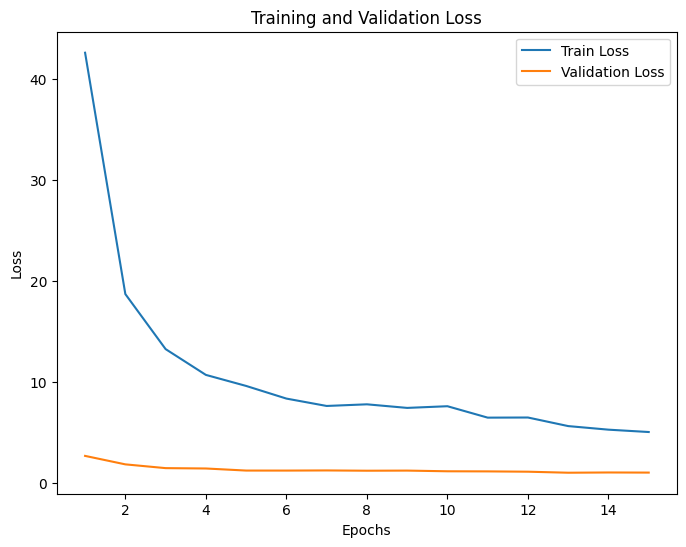

In [ ]:
import matplotlib.pyplot as plt  # Import Matplotlib for plotting

# Create a list of epoch numbers starting from 1
epochs = list(range(1, len(train_loss_history) + 1))

# Set the figure size for better readability
plt.figure(figsize=(8, 6))

# Plot the training loss over epochs
plt.plot(epochs, train_loss_history, label='Train Loss')

# Plot the validation loss over epochs
plt.plot(epochs, val_loss_history, label='Validation Loss')

# Add labels to the axes
plt.xlabel('Epochs')  # Label for the x-axis (number of epochs)
plt.ylabel('Loss')  # Label for the y-axis (loss value)

# Add a legend to differentiate between training and validation loss
plt.legend()

# Add a title to the plot
plt.title('Training and Validation Loss')

# Display the plot
plt.show()

### **IOU (Intersection over Union) Visualization**

- This code plots the **IOU (Intersection over Union)** values for both training and validation datasets over epochs.
- IOU is a key metric in segmentation tasks, measuring how well the model's predicted regions overlap with the ground truth.
- `train_dataset_iou` and `val_dataset_iou` store the IOU values from each epoch for training and validation.
- The x-axis represents the number of epochs, while the y-axis represents the IOU values.
- A higher IOU score indicates better model performance.
- If the training IOU keeps increasing while the validation IOU stagnates or decreases, it may indicate **overfitting**.

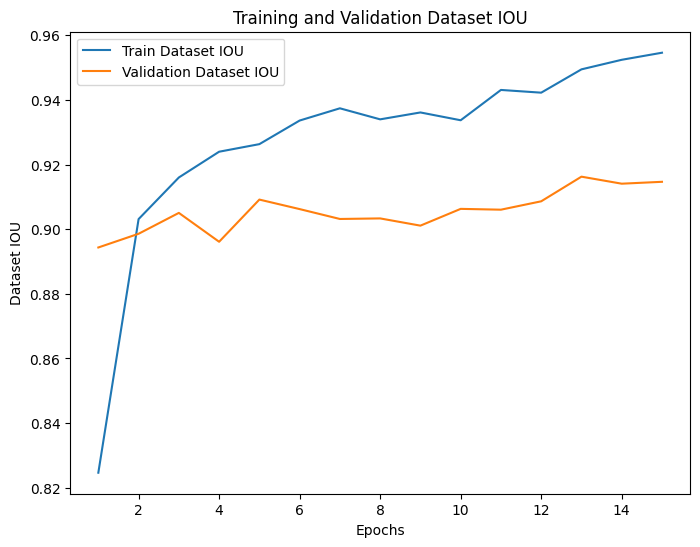

In [ ]:
# Extracting IOU values from stored metric history
train_dataset_iou = [metric['train_dataset_iou'] for metric in train_metric_history]  # Training dataset IOU per epoch
val_dataset_iou = [metric['val_dataset_iou'] for metric in val_metric_history]  # Validation dataset IOU per epoch

# Create a list of epoch numbers starting from 1
epochs = list(range(1, len(train_dataset_iou) + 1))

# Set figure size for better readability
plt.figure(figsize=(8, 6))

# Plot the training IOU over epochs
plt.plot(epochs, train_dataset_iou, label='Train Dataset IOU')

# Plot the validation IOU over epochs
plt.plot(epochs, val_dataset_iou, label='Validation Dataset IOU')

# Add labels to the axes
plt.xlabel('Epochs')  # X-axis label: Number of epochs
plt.ylabel('Dataset IOU')  # Y-axis label: IOU score

# Add a legend to differentiate between training and validation IOU
plt.legend()

# Add a title to the plot
plt.title('Training and Validation Dataset IOU')

# Display the plot
plt.show()

### **Plotting Ground Truth versus Prediction**

- A **batch of test images** is retrieved from `test_dataloader`, and predictions are made using the trained model.
- The model is set to **evaluation mode (`model.eval()`)** to disable dropout and batch normalization effects.
- The predictions (`pr_masks`) are generated using `sigmoid()`, which converts raw logits into probability values between 0 and 1.
- For each image in the batch:
  - **Original image** is displayed.
  - **Ground truth mask** (the actual segmentation) is displayed.
  - **Predicted mask** (model's output) is displayed.
- These images are plotted side-by-side to **compare model performance visually**.
- The `.squeeze()` function is used to remove the extra class dimension since we have only one class.

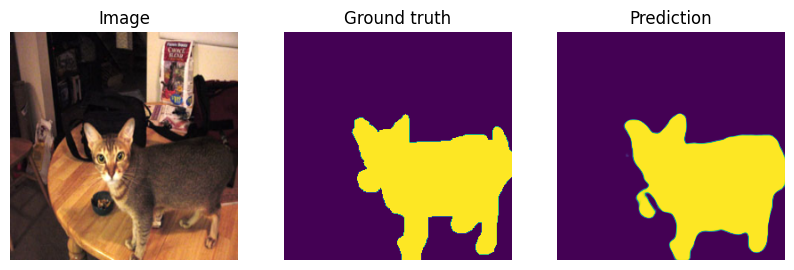

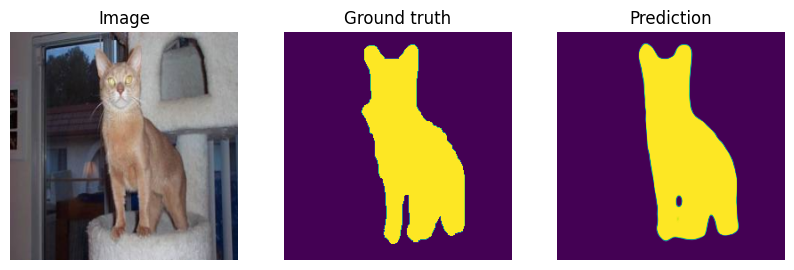

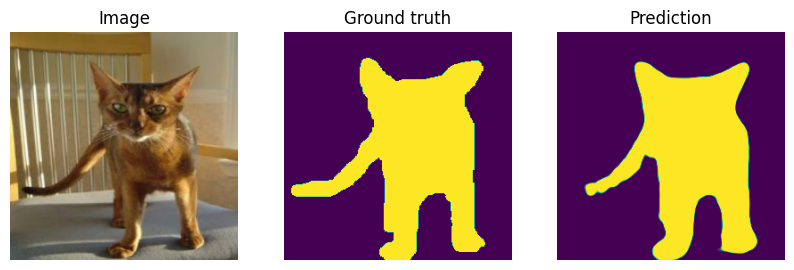

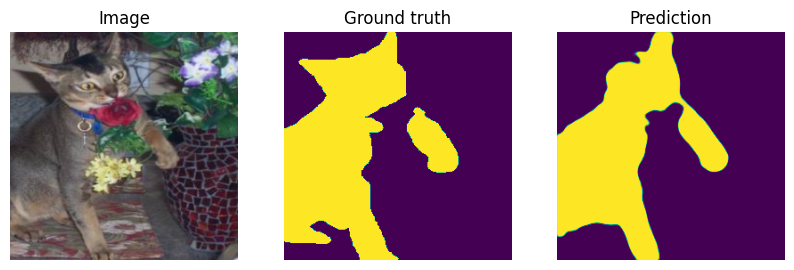

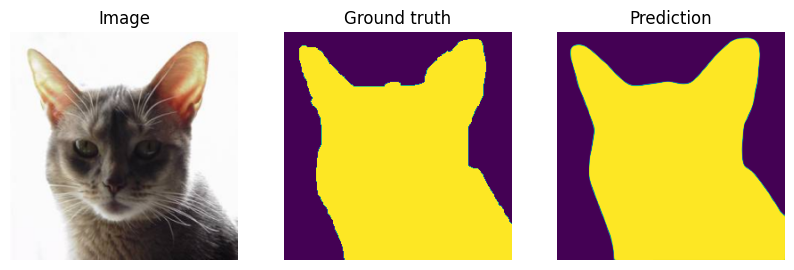

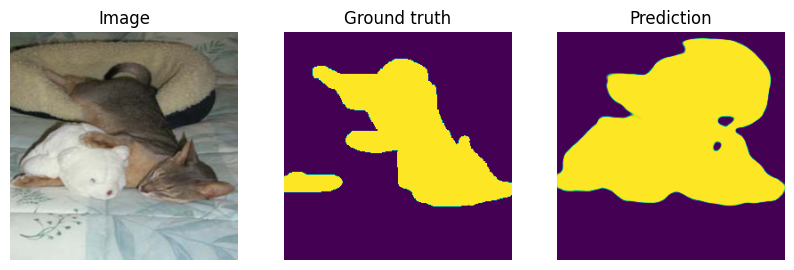

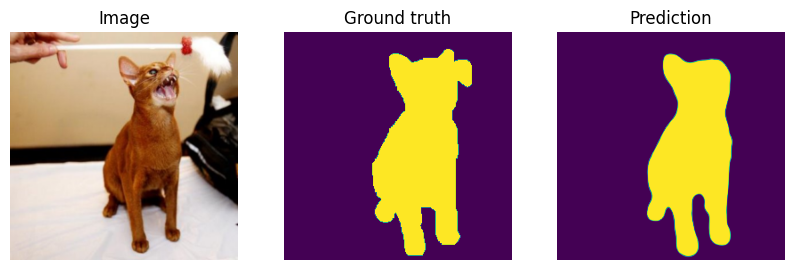

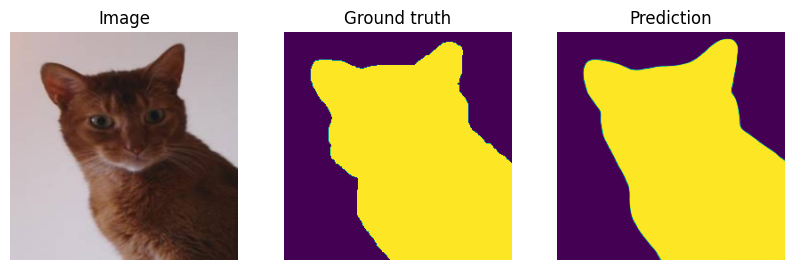

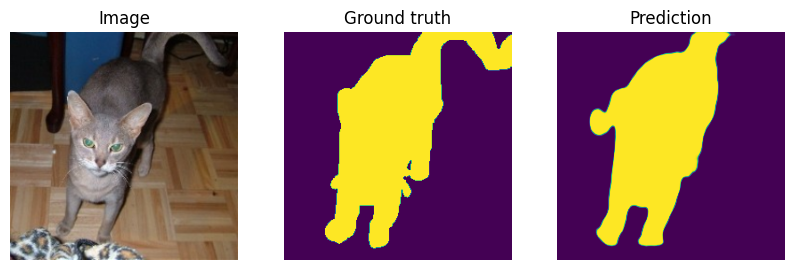

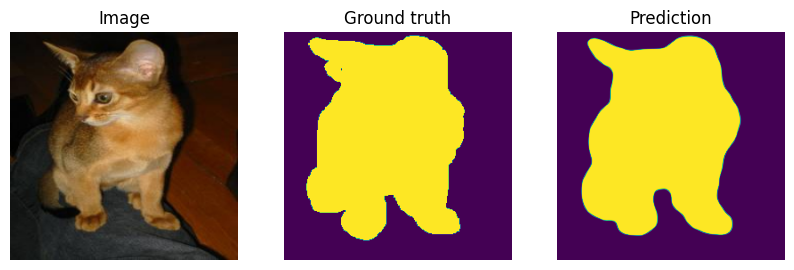

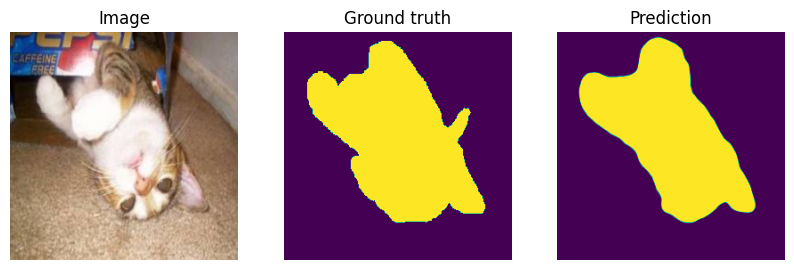

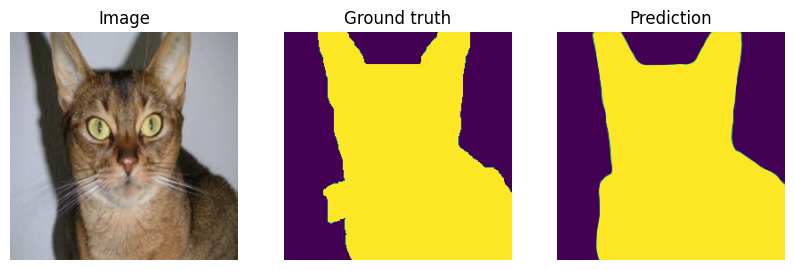

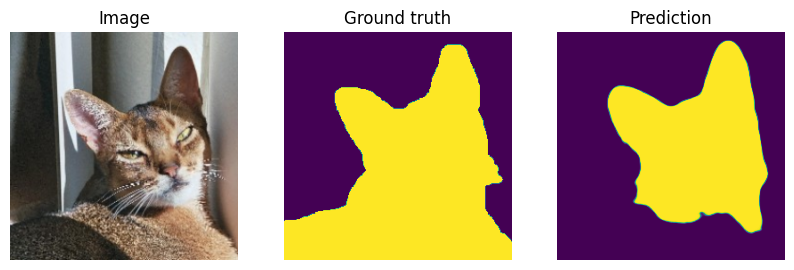

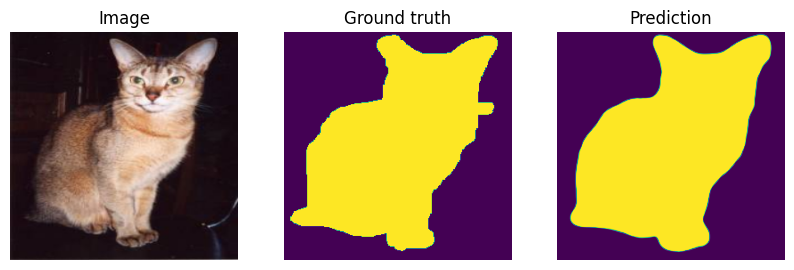

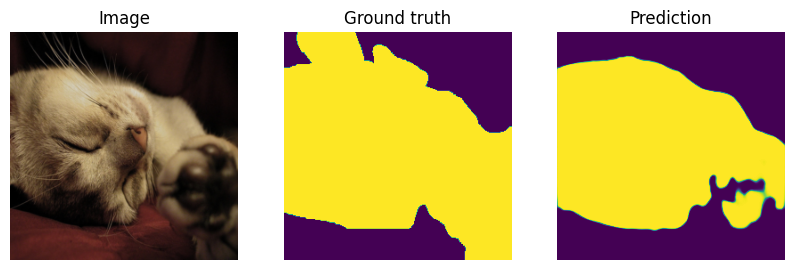

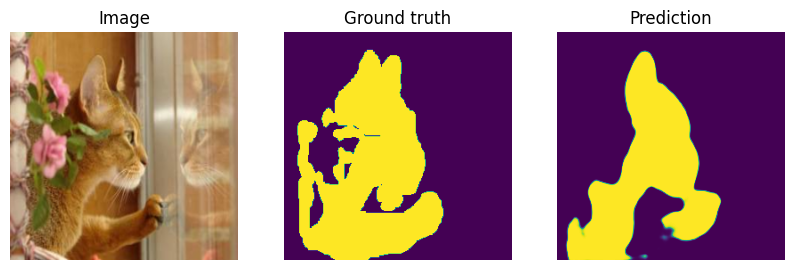

In [ ]:
# Get a batch of test images from the dataloader
batch = next(iter(test_dataloader))

# Disable gradient calculation for inference
with torch.no_grad():
    model.eval()  # Set the model to evaluation mode (disables training behaviors like dropout)

    # Extract the image tensor from the batch and move it to the appropriate device (GPU/CPU)
    image = batch["image"].to(device)

    # Get model predictions (logits)
    logits = model(image)

    # Apply sigmoid activation to convert logits to probabilities (for binary segmentation)
    pr_masks = logits.sigmoid()

# Loop through the batch and plot the results
for image, gt_mask, pr_mask in zip(batch["image"], batch["mask"], pr_masks):
    plt.figure(figsize=(10, 5))  # Set figure size

    # Plot original image
    plt.subplot(1, 3, 1)
    plt.imshow(image.numpy().transpose(1, 2, 0))  # Convert from CHW (Channels-Height-Width) to HWC
    plt.title("Image")
    plt.axis("off")  # Hide axis ticks

    # Plot ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask.numpy().squeeze())  # Remove extra dimensions
    plt.title("Ground Truth")
    plt.axis("off")

    # Plot predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(pr_mask.cpu().numpy().squeeze())  # Move to CPU and remove extra dimensions
    plt.title("Prediction")
    plt.axis("off")

    # Display the plots
    plt.show()


### **Interpreting the Results**

This section explains how to analyze the model's performance, interpret trends in metrics, and identify potential issues like overfitting or underfitting.

## 1. Understanding the Loss Curves

We plotted **training loss** and **validation loss** over epochs to track model performance.

- **Training loss** should gradually decrease as the model learns.
- **Validation loss** should also decrease, but not significantly slower than training loss.

### How to Interpret the Graph?
- **Ideal Case:** Both losses decrease smoothly, indicating good learning.
- **Overfitting:** Training loss decreases, but validation loss stagnates or increases. The model memorizes training data but fails on unseen data.
  - **Solution:** Use dropout, regularization, or more data augmentation.
- **Underfitting:** Both losses remain high and do not improve. The model is not learning enough.
  - **Solution:** Train for more epochs, use a more complex model, or improve data quality.

## 2. Understanding IOU (Intersection over Union)

IOU measures how well the predicted segmentation matches the ground truth. Higher IOU means better segmentation accuracy.

### How to Interpret the Graph?
- **Ideal Case:** Both training and validation IOU increase steadily.
- **Overfitting:** Training IOU keeps increasing, but validation IOU stagnates or drops.
  - **Solution:** Use early stopping, regularization, or more diverse training data.
- **Underfitting:** Both training and validation IOU remain low, meaning the model is not learning well.
  - **Solution:** Improve model architecture, increase training epochs, or tune hyperparameters.

## 3. Visualizing Predictions: Ground Truth vs. Model Output

We visualized:
1. **Original Image**
2. **Ground Truth Mask** (correct segmentation)
3. **Predicted Mask** (model's output)

### How to Analyze the Results?
- If the predicted mask closely matches the ground truth, the model is performing well.
- If there are major differences, the model needs improvement.

### Common Issues:
- **Missing parts of the object:** The model is not detecting complete shapes.
- **Blurry or unclear boundaries:** The model struggles with precise segmentation.
- **Over-segmentation:** The model predicts extra regions.
- **Under-segmentation:** The model predicts too little.

**Solutions:** Improve training data, use better loss functions, fine-tune the model.

## Final Thoughts

Interpreting results correctly helps in making informed decisions to improve the model. The focus should be on creating a model that generalizes well rather than just reducing loss. Experimenting with different strategies is key to achieving better performance.
